character level language model! predict next character based words in a dataset

In [ ]:
words = open('names.txt','r').read().splitlines() # create list of words from text file based on linesplits as delineators

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [ ]:
min(len(w) for w in words) # find length of shortest word

2

In [5]:
max(len(w) for w in words) # find length of longest word

15

In [ ]:
# can it predict another sequence given a sequence of characters before us?
# structure of a word contains lots of information:
# what letters are likely to come after other letters, when a word is likely to end.
# bigram: only consider 2 characters at a time. look at one character, what character is likely to come next? model local structure

In [14]:
# count how often bigrams appear in dataset
b = {} # dictionary, keep track of how often each bigram occurs

for w in words:
    chs = ['<S>'] + list(w) + ['<E>'] # wrap list of chars in word in special start and end characters
    for ch1, ch2 in zip(chs, chs[1:]): # by omitting the first character of the word from the second iterator passed to zip(), it gives the leading chars, followed by the trailing chars, to end of word as second element in final tuple
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1 # for each bigram, enter and initialize at 0. for each repeated instance of bigram, add one to count for that bigram in dict

In [82]:
# store info in a 2d array, rows will be first character, columns will be second char, entry will say how often the pair occurs
# will use torch to build array
import torch

In [83]:
# 2d array to contain bigram frequencies
N = torch.zeros((27, 27), dtype=torch.int32) # create array of zeros as integers. 28 by 28. will have all chars incl. special as first of rows and columns, then intersect will show frequency of occurence that the second comes after the first

In [84]:
chars = sorted(list(set(''.join(words)))) # concatenate all chars, set removes duplicates
stoi = {s:i+1 for i,s in enumerate(chars)} # string to int dictionary, map char to int
stoi['.'] = 0 # add special chars
itos = {i:s for s,i in stoi.items()} # convert int representations back to string (chars)

In [85]:
# need lookup table from chars to ints so that chars can be represented as ints in array
for w in words:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        # populate array
        ix1 = stoi[ch1] # get position of character 1 in bigram
        ix2 = stoi[ch2] # get position of character 2 in bigram
        N[ix1, ix2] += 1 # where ix1 and ix2 both exist, add 1

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

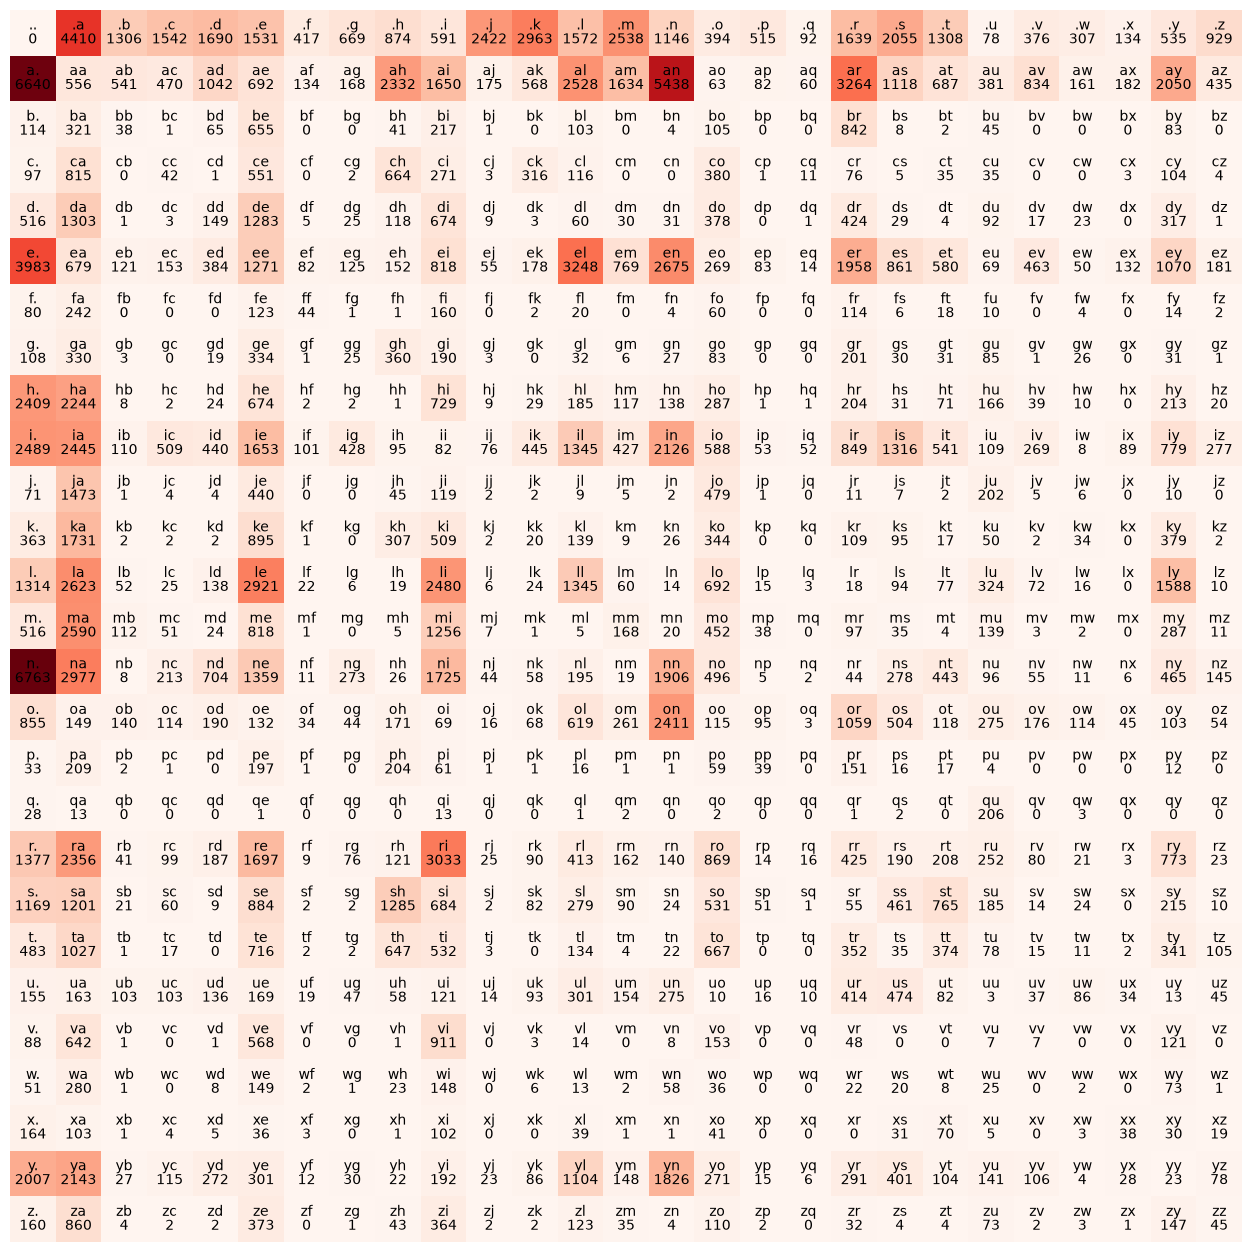

In [86]:
import matplotlib.pyplot as plt
%matplotlib inline

#visualize frequencies
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Reds')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='black')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='black')
plt.axis('off')

In [87]:
N[0] # 0th row

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [88]:
#convert to probabilities (normalize counts)
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [93]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item() # sample an index from the distribution of first letter occurences
itos[ix]

'd'

In [64]:
#sample from distribution use Torch.multinomial. you give me probabilities, i give you integers sampled according to the probability distribution
#generator object with set seed for repeatability
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [92]:
torch.multinomial(p, num_samples=20, replacement=True, generator=g) # replacement = True draws element and replaces it with probability distribution (number of times each element of index appears)
# see: small number of 2 (small probability), lots of 0 indices, some 1 indices.

tensor([ 0, 13, 20, 22,  8, 25,  0, 13, 20,  3,  4, 14,  0, 14, 14, 12,  0, 14,
        22, 18])

In [120]:
P.sum(1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [126]:
# create probability matrix beforehand for efficiency
# broadcasting semantics (can arrays be combined in different operations?) be careful!
P = N.float()
P /= P.sum(1, keepdim=True) # need to sum across rows (0th dimension) and not lose the columns (keepdim=True)

In [127]:
# start predicting
g = torch.Generator().manual_seed(2147483647)


for i in range(5):
    out =[] # outputs

    ix = 0
    while True:
        
        
        p = P[ix] # use precalculated probability distribution
        # p = N[ix].float() # grab element from array
        # p = p / p.sum() # normalize
        # p = torch.ones(27) / 27.0
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item() # grab sample
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
